In [8]:
!rmdir %cd%\openapi_client\ /s /q
!docker run --rm -v %cd%:/local openapitools/openapi-generator-cli generate -i /local/Ebay.yaml -g python-pydantic-v1 -o /local/client --additional-properties=generateSourceCodeOnly=true
!move %cd%/client/openapi_client %cd%/openapi_client
!rmdir %cd%\client\ /s /q

[main] INFO  o.o.codegen.DefaultGenerator - Generating with dryRun=false
[main] INFO  o.o.c.ignore.CodegenIgnoreProcessor - Output directory (/local/client) does not exist, or is inaccessible. No file (.openapi-generator-ignore) will be evaluated.
[main] INFO  o.o.codegen.DefaultGenerator - OpenAPI Generator: python-pydantic-v1 (client)
[main] INFO  o.o.codegen.DefaultGenerator - Generator 'python-pydantic-v1' is considered stable.
[main] INFO  o.o.c.l.AbstractPythonPydanticV1Codegen - Environment variable PYTHON_POST_PROCESS_FILE not defined so the Python code may not be properly formatted. To define it, try 'export PYTHON_POST_PROCESS_FILE="/usr/local/bin/yapf -i"' (Linux/Mac)
[main] INFO  o.o.c.l.AbstractPythonPydanticV1Codegen - NOTE: To enable file post-processing, 'enablePostProcessFile' must be set to `true` (--enable-post-process-file for CLI).
[main] INFO  o.o.c.l.PythonPydanticV1ClientCodegen - Environment variable PYTHON_POST_PROCESS_FILE not defined so the Python code may n

In [10]:
from client.openapi_client import LotInfoShort, ProductWithId
from client.openapi_client import ApiClient, Configuration
from client.openapi_client.api import DefaultApi
import requests
import pandas as pd
from typing import List
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from datetime import datetime

ModuleNotFoundError: No module named 'openapi_client'

In [2]:
server = "naks42.ru"
port = 17443
clientId = "Ebay.Python"
secret = "ac4ab670-ae20-451a-ab4a-3a20275e807d"

In [3]:
#unknown_price_discount = 0.7

In [4]:
def get_access_token(url, client_id, client_secret):
    response = requests.post(
        url,
        data={"grant_type": "client_credentials"},
        auth=(client_id, client_secret),
    )
    return response.json()["access_token"]

token = get_access_token(f"https://{server}:{port}/connect/token", clientId, secret)

client = ApiClient(
    configuration=Configuration(host=f'https://{server}:{port}/api/ebay/v1'), header_name='Authorization',
    header_value='Bearer ' + token)

api = DefaultApi(client)

In [38]:
currencies = api.get_currencies()
currency_rates = {}
for currency in currencies:
    if (datetime.now() - datetime.strptime(currencies[0].last_update, '%Y-%m-%dT%H:%M:%S.%fZ')).days > 1:
        raise Exception("exchange rate isn't accurate " + currency.ebay_name)
    currency_rates[currency.ebay_name] = currency.rate

productRowsExcluded = {'search_queries'}
lotRowsExcluded = {'seller', 'located_in', 'purchase_history'}
purchaseExcluded = {}

products: List[ProductWithId] = api.get_all_products()
df = pd.DataFrame()

for product in products:
    print(f'Processing {product.name}')
    lots: List[LotInfoShort] = api.get_lots(product_id=product.id)
    
    productRow = {}
    for key, value in product.__dict__.items():
        if key not in productRowsExcluded:
            productRow[f'product_{key}'] = value
        
    dataFrameArray = []
    for lot in lots:
        lotRow = productRow.copy()
        for key, value in lot.__dict__.items():
            if key not in lotRowsExcluded:
                lotRow[f'lot_{key}'] = value
                
        for purchase in lot.purchase_history:
            purchaseRow = lotRow.copy()
            for key, value in purchase.__dict__.items():
                if key not in purchaseExcluded:
                    purchaseRow[f'purchase_{key}'] = value
            dataFrameArray.append(purchaseRow)

    df = pd.concat([df, pd.DataFrame(dataFrameArray)], ignore_index=True)

Processing 12Z1L POLAM
Processing 12Ж1Л
Processing 12П17Л
Processing 1Б10-17
Processing 2Ж27Л
Processing 6CC31 TESLA
Processing 6Е1П
Processing 6Е3П
Processing 6И1П
Processing 6И1П-ЕВ
Processing 6Н15П
Processing 6Н16Б-В
Processing 6Н18Б-В
Processing 6Н1П
Processing 6Н1П-В
Processing 6Н1П-ВИ
Processing 6Н1П-Е
Processing 6Н1П-ЕВ
Processing 6Н1П-ЕВ СОВТЕК
Processing 6Н1П Совтек
Processing 6Н2П
Processing 6Н2П-В
Processing 6Н2П-Е
Processing 6Н2П-ЕВ
Processing 6Н2П-ЕР
Processing 6Н2П КИТАЙ
Processing 6Н3П
Processing 6Н3П-ДР
Processing 6Н3П-Е
Processing 6Н3П-ЕВ
Processing 6Н3П-И
Processing 6Н5П
Processing 6Н7С
Processing 6Н9С
Processing 6П13С
Processing 6П14П
Processing 6П14П-В
Processing 6П14П-ЕВ
Processing 6П14П-ЕР
Processing 6П14П-К
Processing 6П15П
Processing 6П15П-ЕВ
Processing 6П15П-ЕР
Processing 6П1П
Processing 6П1П-В
Processing 6П1П-Е
Processing 6П1П-ЕВ
Processing 6П21С
Processing 6П7С
Processing 6С19П
Processing 6С19П-В
Processing 6С19П-ВР
Processing 6С1П
Processing 6С2П
Processing 

In [47]:
df[(df.lot_price - df.purchase_price).abs() > df.lot_price * 0.5]

,product_id,product_name,product_last_check_time,lot_lot_id,lot_name,lot_pcs,lot_shipping_country,lot_currency,lot_price,lot_shipping,lot_shipping_additional,lot_condition,lot_condition_description,lot_manual_condition_id,purchase_price,purchase_quantity,purchase_var_date,exchange_rate,purchase_price_filled_nulls
402,e0b1ba31-1b7b-443f-92a4-7cab05d7c1df,6Н1П-ЕВ,1970-01-01T00:00:00.000Z,166222502210,6N1P-EV ( 6Н1П-ЕВ ) USSR Military Dual Triode ...,1,Latvia,US $,6.50,11.00,11.0,New,None,newNotTested,1.8,250,2023-11-10T12:44:26.000Z,1.000000,1.8
568,4ef731bb-48fa-4552-bd63-937936e488e7,6Н2П,1970-01-01T00:00:00.000Z,196054479790,"50PCS 6N2P ~ 12AX7, ECC83 Double Triode Tube S...",50,Germany,US $,104.50,27.99,0.0,Used,NOS (new old stock) / NEVER USED & Slightly Used,newNotTested,29.66,1,2023-12-17T16:13:31.000Z,1.000000,29.66
569,4ef731bb-48fa-4552-bd63-937936e488e7,6Н2П,1970-01-01T00:00:00.000Z,196054479790,"50PCS 6N2P ~ 12AX7, ECC83 Double Triode Tube S...",50,Germany,US $,104.50,27.99,0.0,Used,NOS (new old stock) / NEVER USED & Slightly Used,newNotTested,29.66,1,2023-12-17T14:53:10.000Z,1.000000,29.66
570,4ef731bb-48fa-4552-bd63-937936e488e7,6Н2П,1970-01-01T00:00:00.000Z,196054479790,"50PCS 6N2P ~ 12AX7, ECC83 Double Triode Tube S...",50,Germany,US $,104.50,27.99,0.0,Used,NOS (new old stock) / NEVER USED & Slightly Used,newNotTested,29.66,1,2023-12-17T03:01:32.000Z,1.000000,29.66
571,4ef731bb-48fa-4552-bd63-937936e488e7,6Н2П,1970-01-01T00:00:00.000Z,196054479790,"50PCS 6N2P ~ 12AX7, ECC83 Double Triode Tube S...",50,Germany,US $,104.50,27.99,0.0,Used,NOS (new old stock) / NEVER USED & Slightly Used,newNotTested,29.66,1,2023-12-15T03:36:57.000Z,1.000000,29.66
572,4ef731bb-48fa-4552-bd63-937936e488e7,6Н2П,1970-01-01T00:00:00.000Z,196054479790,"50PCS 6N2P ~ 12AX7, ECC83 Double Triode Tube S...",50,Germany,US $,104.50,27.99,0.0,Used,NOS (new old stock) / NEVER USED & Slightly Used,newNotTested,29.66,1,2023-12-10T10:14:44.000Z,1.000000,29.66
573,4ef731bb-48fa-4552-bd63-937936e488e7,6Н2П,1970-01-01T00:00:00.000Z,196054479790,"50PCS 6N2P ~ 12AX7, ECC83 Double Triode Tube S...",50,Germany,US $,104.50,27.99,0.0,Used,NOS (new old stock) / NEVER USED & Slightly Used,newNotTested,29.66,1,2023-11-29T11:06:48.000Z,1.000000,29.66
574,4ef731bb-48fa-4552-bd63-937936e488e7,6Н2П,1970-01-01T00:00:00.000Z,196054479790,"50PCS 6N2P ~ 12AX7, ECC83 Double Triode Tube S...",50,Germany,US $,104.50,27.99,0.0,Used,NOS (new old stock) / NEVER USED & Slightly Used,newNotTested,29.66,1,2023-11-26T08:48:35.000Z,1.000000,29.66
575,4ef731bb-48fa-4552-bd63-937936e488e7,6Н2П,1970-01-01T00:00:00.000Z,196054479790,"50PCS 6N2P ~ 12AX7, ECC83 Double Triode Tube S...",50,Germany,US $,104.50,27.99,0.0,Used,NOS (new old stock) / NEVER USED & Slightly Used,newNotTested,34.9,1,2023-11-12T13:39:01.000Z,1.000000,34.9
576,4ef731bb-48fa-4552-bd63-937936e488e7,6Н2П,1970-01-01T00:00:00.000Z,196054479790,"50PCS 6N2P ~ 12AX7, ECC83 Double Triode Tube S...",50,Germany,US $,104.50,27.99,0.0,Used,NOS (new old stock) / NEVER USED & Slightly Used,newNotTested,34.9,1,2023-11-06T02:47:33.000Z,1.000000,34.9


In [41]:
#df['purchase_price_filled_nulls'] = df.purchase_price.fillna(df.lot_price * unknown_price_discount)
df.dropna(subset=['purchase_price'], inplace=True)
df['purchase_price_filled_nulls'] = df.purchase_price
df['exchange_rate'] = df.lot_currency.map(currency_rates)

In [17]:
df = df[(df.product_name == '6П14П')]

In [18]:
df['lot_manual_condition_id'].value_counts()

lot_manual_condition_id
usedAndMatched      273
usedAndNotTested     46
usedAndTested        45
newAndMatched        38
newAndTested         17
newNotTested         11
Name: count, dtype: int64

In [27]:
df['purchase_total_price'] = df.purchase_price_filled_nulls * df.purchase_quantity + df.lot_shipping + (df.lot_shipping_additional * (df.purchase_quantity - 1))
df['purchase_total_price_usd'] = df.purchase_total_price / df.exchange_rate
df['total_price_per_pcs_usd'] = df.purchase_total_price_usd / (df.lot_pcs * df.purchase_quantity)

In [28]:
df

,product_id,product_name,product_last_check_time,lot_lot_id,lot_name,lot_pcs,lot_shipping_country,lot_currency,lot_price,lot_shipping,...,lot_condition_description,lot_manual_condition_id,purchase_price,purchase_quantity,purchase_var_date,purchase_price_filled_nulls,exchange_rate,purchase_total_price,purchase_total_price_usd,total_price_per_pcs_usd
1131,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,115043977132,10 PCS 6P14P / EL84 / 6BQ5 Vacuum Pentode Tube...,10,Germany,US $,19.0,8.95,...,"Previously, vacuum tubes were used. Good condi...",usedAndNotTested,NaN,2,2024-01-29T11:27:01.000Z,13.30,1.0,44.50,44.50,2.2250
1132,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,115043977132,10 PCS 6P14P / EL84 / 6BQ5 Vacuum Pentode Tube...,10,Germany,US $,19.0,8.95,...,"Previously, vacuum tubes were used. Good condi...",usedAndNotTested,NaN,3,2024-01-22T15:43:43.000Z,13.30,1.0,66.75,66.75,2.2250
1133,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,115043977132,10 PCS 6P14P / EL84 / 6BQ5 Vacuum Pentode Tube...,10,Germany,US $,19.0,8.95,...,"Previously, vacuum tubes were used. Good condi...",usedAndNotTested,17.0,1,2024-01-19T17:33:53.000Z,17.00,1.0,25.95,25.95,2.5950
1134,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,115043977132,10 PCS 6P14P / EL84 / 6BQ5 Vacuum Pentode Tube...,10,Germany,US $,19.0,8.95,...,"Previously, vacuum tubes were used. Good condi...",usedAndNotTested,17.0,1,2024-01-19T03:54:36.000Z,17.00,1.0,25.95,25.95,2.5950
1135,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,115043977132,10 PCS 6P14P / EL84 / 6BQ5 Vacuum Pentode Tube...,10,Germany,US $,19.0,8.95,...,"Previously, vacuum tubes were used. Good condi...",usedAndNotTested,NaN,4,2023-12-28T15:46:47.000Z,13.30,1.0,89.00,89.00,2.2250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1556,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,394134039609,6P14P 4pcs USED TESTED MATCHED QUAD REFLECTOR ...,4,Germany,US $,7.5,9.50,...,USED / TESTED /SEE CONDITION AT THE PHOTO,usedAndMatched,7.5,1,2023-11-26T18:30:21.000Z,7.50,1.0,17.00,17.00,4.2500
1557,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,394134039609,6P14P 4pcs USED TESTED MATCHED QUAD REFLECTOR ...,4,Germany,US $,7.5,9.50,...,USED / TESTED /SEE CONDITION AT THE PHOTO,usedAndMatched,NaN,4,2023-09-04T21:56:47.000Z,5.25,1.0,41.00,41.00,2.5625
1558,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,394134039609,6P14P 4pcs USED TESTED MATCHED QUAD REFLECTOR ...,4,Germany,US $,7.5,9.50,...,USED / TESTED /SEE CONDITION AT THE PHOTO,usedAndMatched,NaN,1,2023-04-30T08:10:44.000Z,5.25,1.0,14.75,14.75,3.6875
1559,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,394134039609,6P14P 4pcs USED TESTED MATCHED QUAD REFLECTOR ...,4,Germany,US $,7.5,9.50,...,USED / TESTED /SEE CONDITION AT THE PHOTO,usedAndMatched,NaN,4,2023-02-20T07:55:42.000Z,5.25,1.0,41.00,41.00,2.5625


array([[<Axes: title={'center': 'newAndMatched'}>,
        <Axes: title={'center': 'newAndTested'}>],
       [<Axes: title={'center': 'newNotTested'}>,
        <Axes: title={'center': 'usedAndMatched'}>],
       [<Axes: title={'center': 'usedAndNotTested'}>,
        <Axes: title={'center': 'usedAndTested'}>]], dtype=object)

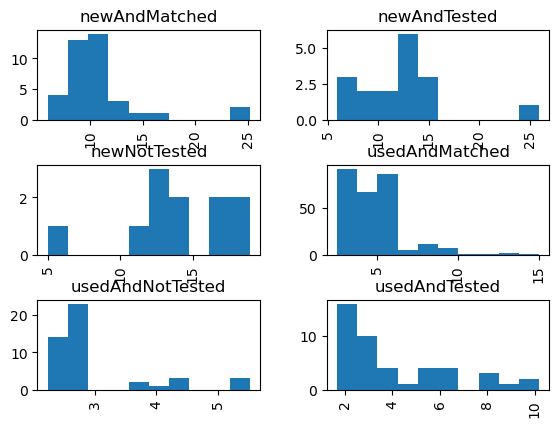

In [29]:
df.hist('total_price_per_pcs_usd', by='lot_manual_condition_id')

In [30]:
df[df.lot_manual_condition_id == 'newAndMatched']

,product_id,product_name,product_last_check_time,lot_lot_id,lot_name,lot_pcs,lot_shipping_country,lot_currency,lot_price,lot_shipping,...,lot_condition_description,lot_manual_condition_id,purchase_price,purchase_quantity,purchase_var_date,purchase_price_filled_nulls,exchange_rate,purchase_total_price,purchase_total_price_usd,total_price_per_pcs_usd
1155,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,115600325335,6P14P MATCHED PAIR REFLECTOR NEW 1960-69 YEARS...,2,Germany,US $,22.00,10.00,...,None,newAndMatched,22.0,1,2024-01-06T04:23:31.000Z,22.00,1.0,32.00,32.00,16.000000
1156,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,115600325335,6P14P MATCHED PAIR REFLECTOR NEW 1960-69 YEARS...,2,Germany,US $,22.00,10.00,...,None,newAndMatched,42.0,2,2023-11-17T04:47:22.000Z,42.00,1.0,94.00,94.00,23.500000
1304,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,133475288040,4PCS 6P14P/ EL84 / 6BQ5 REFLECTOR SELECTED QUA...,4,Germany,US $,35.00,11.00,...,NOS! TESTED! ALL TUBES Ia=45mA,newAndMatched,35.0,1,2024-01-29T14:27:05.000Z,35.00,1.0,46.00,46.00,11.500000
1305,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,133475288040,4PCS 6P14P/ EL84 / 6BQ5 REFLECTOR SELECTED QUA...,4,Germany,US $,35.00,11.00,...,NOS! TESTED! ALL TUBES Ia=45mA,newAndMatched,35.0,1,2024-01-22T05:58:13.000Z,35.00,1.0,46.00,46.00,11.500000
1306,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,133475288040,4PCS 6P14P/ EL84 / 6BQ5 REFLECTOR SELECTED QUA...,4,Germany,US $,35.00,11.00,...,NOS! TESTED! ALL TUBES Ia=45mA,newAndMatched,NaN,1,2024-01-20T13:28:22.000Z,24.50,1.0,35.50,35.50,8.875000
1400,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,None,newAndMatched,34.0,1,2024-01-29T14:27:05.000Z,34.00,1.0,46.00,46.00,11.500000
1401,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,None,newAndMatched,34.0,1,2024-01-12T17:14:23.000Z,34.00,1.0,46.00,46.00,11.500000
1402,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,None,newAndMatched,34.0,1,2024-01-04T12:06:40.000Z,34.00,1.0,46.00,46.00,11.500000
1403,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,None,newAndMatched,34.0,1,2024-01-04T08:42:41.000Z,34.00,1.0,46.00,46.00,11.500000
1404,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,None,newAndMatched,34.0,1,2024-01-02T19:57:54.000Z,34.00,1.0,46.00,46.00,11.500000


In [31]:
df[df.lot_manual_condition_id == 'newAndMatched'][["lot_lot_id","total_price_per_pcs_usd", "purchase_total_price_usd", "lot_pcs", "purchase_quantity"]]

,lot_lot_id,total_price_per_pcs_usd,purchase_total_price_usd,lot_pcs,purchase_quantity
1155,115600325335,16.000000,32.00,2,1
1156,115600325335,23.500000,94.00,2,2
1304,133475288040,11.500000,46.00,4,1
1305,133475288040,11.500000,46.00,4,1
1306,133475288040,8.875000,35.50,4,1
1400,145191346462,11.500000,46.00,4,1
1401,145191346462,11.500000,46.00,4,1
1402,145191346462,11.500000,46.00,4,1
1403,145191346462,11.500000,46.00,4,1
1404,145191346462,11.500000,46.00,4,1
